# MINIMAL AMAZIGH TATTOO GENERATOR (Yirawen)

**for now i didn't customize any specifique amazigh datasets for fine tuning**

**Step 1: Install libraries**

In [1]:

!pip install -q diffusers transformers accelerate safetensors peft

print("✅ Libraries installed!")

✅ Libraries installed!


**Step 2: Import what is needed**

In [2]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import os

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


**Step 3: Check GPU**

In [3]:
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU available: True
GPU: Tesla T4


**Step 4: Loading the base model**

In [29]:
USE_SDXL = False  # Set to True if you have enough GPU memory

if USE_SDXL:
    print("⏳ Loading SDXL... (high quality, slower)")
    model = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16,
        variant="fp16",
        use_safetensors=True
    ).to("cuda")
    model.enable_vae_slicing()  # Save memory
else:
    print("⏳ Loading Stable Diffusion 1.5... (faster)")
    model = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16,
        safety_checker=None,
        requires_safety_checker=False
    ).to("cuda")
    model.enable_attention_slicing()

print("✅ Model ready!")

⏳ Loading Stable Diffusion 1.5... (faster)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model ready!


**Step 5: Create a simple dataset function**

In [25]:
def generate_amazigh_tattoo(
    description="geometric pattern",
    style="traditional",
    location="face",
    save=True
):
    """
    Generate Amazigh tattoo designs
    """
    
    # Craft the perfect prompt for Amazigh tattoos
    prompt = f"""
    Traditional Amazigh Berber tattoo, {description}, 
    {style} style, {location} tattoo, 
    geometric patterns, lines and dots, 
    black ink, traditional Yirawen design,
    clean line art, minimalist, authentic,
    white background, high contrast
    """
    
    # What to avoid
    negative = """
    colorful, modern, western, realistic skin, 
    blurry, low quality, photorealistic, 
    3d render, shadow, gradient, soft edges
    """
    
    print(f"🎨 Generating: {description} ({style}, {location})")
    
    # Generate
    image = model(
        prompt=prompt,
        negative_prompt=negative,
        num_inference_steps=25,
        guidance_scale=7.5
    ).images[0]
    
    # Show it
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Amazigh Tattoo: {description}", fontsize=10)
    plt.show()
    
    # Save it
    if save:
        filename = f"amazigh_tattoo_{description.replace(' ', '_')[:20]}.png"
        image.save(filename)
        print(f"💾 Saved as: {filename}")
    
    return image


**Step 6: Generate examples!**

GENERATING AMAZIGH TATTOO DESIGNS
🎨 Generating:  an amazigh symbol  (traditional, chin)


  0%|          | 0/25 [00:00<?, ?it/s]

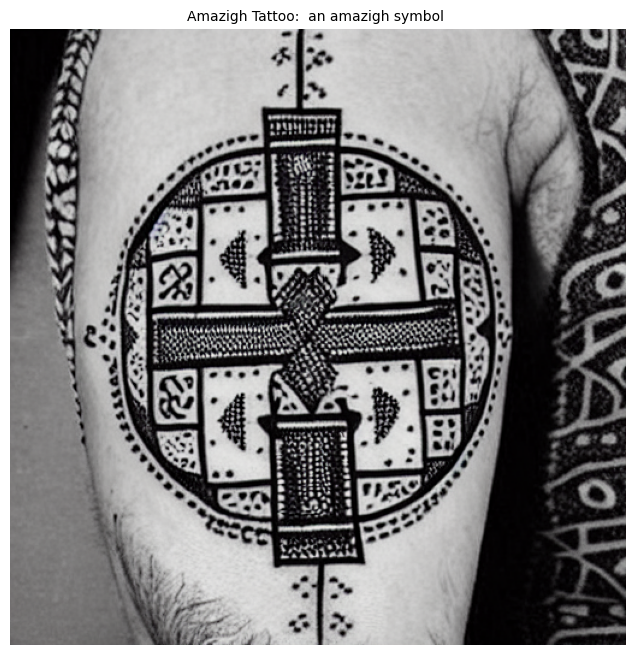

💾 Saved as: amazigh_tattoo__an_amazigh_symbol_.png
🎨 Generating: vertical line with diamond shapes (minimalist, forehead)


  0%|          | 0/25 [00:00<?, ?it/s]

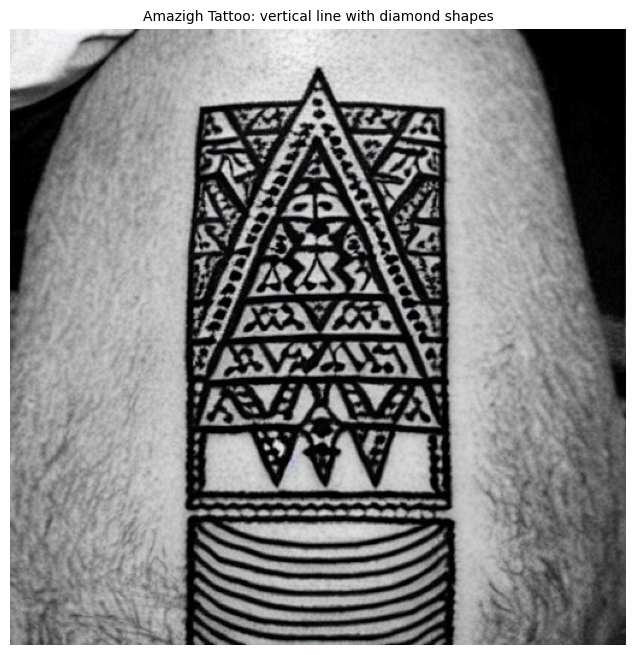

💾 Saved as: amazigh_tattoo_vertical_line_with_d.png
🎨 Generating: intricate hand pattern with sun symbol (ornate, hand)


  0%|          | 0/25 [00:00<?, ?it/s]

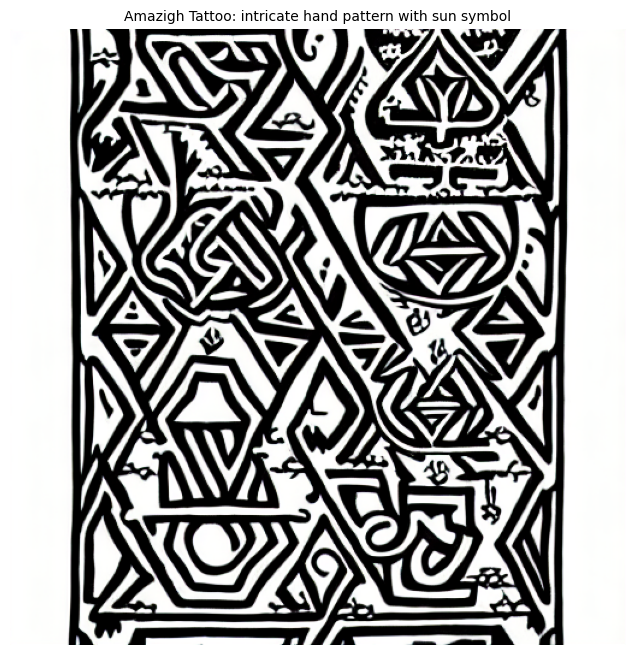

💾 Saved as: amazigh_tattoo_intricate_hand_patte.png


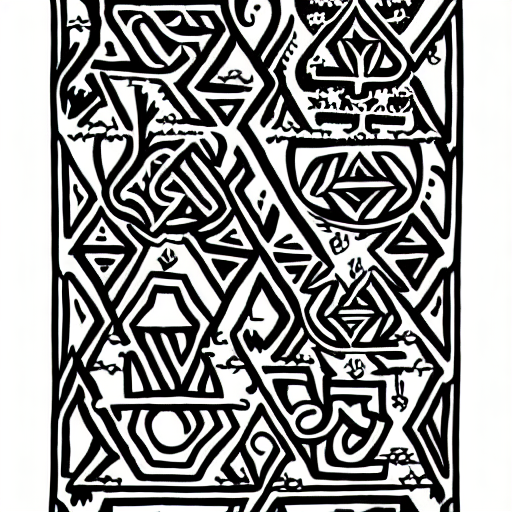

In [27]:

print("=" * 50)
print("GENERATING AMAZIGH TATTOO DESIGNS")
print("=" * 50)

# Example 1: Classic geometric chin tattoo
generate_amazigh_tattoo(
    description=" an amazigh symbol ",
    style="traditional",
    location="chin"
)

# Example 2: Forehead tattoo
generate_amazigh_tattoo(
    description="vertical line with diamond shapes",
    style="minimalist",
    location="forehead"
)

# Example 3: Hand tattoo (henna-inspired but permanent)
generate_amazigh_tattoo(
    description="intricate hand pattern with sun symbol",
    style="ornate",
    location="hand"
)

**Step 7: Interactive function for you to try!**

🎨 Generating: crescent moon with three dots (traditional, forhead)


  0%|          | 0/25 [00:00<?, ?it/s]

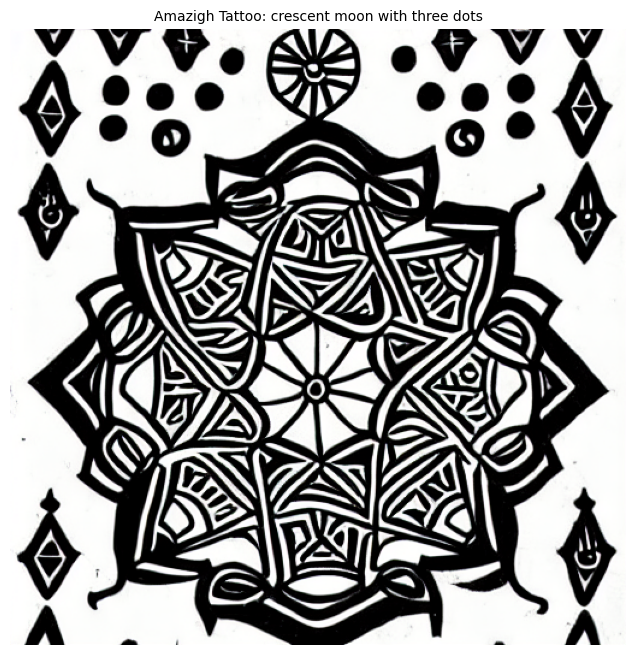

💾 Saved as: amazigh_tattoo_crescent_moon_with_t.png

NEXT STEPS TO MAKE IT BETTER:

1. COLLECT REAL IMAGES:
   - Search Pinterest: 'Berber tattoo', 'Amazigh tattoo', 'Yirawen'
   - Download 20-50 images of traditional tattoos
   - Save as: tattoo_001.jpg, tattoo_002.jpg, etc.

2. CREATE CAPTIONS:
   For each image, create a text file with description:
   tattoo_001.txt -> "vertical line pattern, three dots, chin tattoo"
   tattoo_002.txt -> "diamond fibula shape, forehead tattoo"

3. TRAIN LORA (we'll add this next):
   - Train the model on your specific images
   - It will learn the exact Amazigh style
   - Results will be much more authentic!

4. CULTURAL RESPECT:
   - These tattoos were traditionally for women
   - Some patterns had protective/spiritual meanings
   - Research before commercializing
   - Consider consulting Amazigh cultural experts



In [11]:
def my_tattoo_idea(your_description):
    """
    Use this function to test your own ideas!
    """
    return generate_amazigh_tattoo(
        description=your_description,
        style="traditional",
        location="forhead"
    )

#  A Try :
my_tattoo_idea("crescent moon with three dots")

print("\n" + "=" * 50)
print("NEXT STEPS TO MAKE IT BETTER:")
print("=" * 50)
print("""
1. COLLECT REAL IMAGES:
   - Search Pinterest: 'Berber tattoo', 'Amazigh tattoo', 'Yirawen'
   - Download 20-50 images of traditional tattoos
   - Save as: tattoo_001.jpg, tattoo_002.jpg, etc.

2. CREATE CAPTIONS:
   For each image, create a text file with description:
   tattoo_001.txt -> "vertical line pattern, three dots, chin tattoo"
   tattoo_002.txt -> "diamond fibula shape, forehead tattoo"

3. TRAIN LORA (we'll add this next):
   - Train the model on your specific images
   - It will learn the exact Amazigh style
   - Results will be much more authentic!

""")

# Building a dataset

In [30]:
"""
    📸 HOW TO BUILD YOUR DATASET:
    
    1. Go to Pinterest.com
    2. Search: "Amazigh tattoo traditional"
    3. Search: "Berber facial tattoo"
    4. Search: "Yirawen Morocco"
    5. Search: "Kabyle tattoo Algeria"
    """
    
    # Create folder
    os.makedirs("/kaggle/working/tattoo_dataset", exist_ok=True)
    print("✅ Created folder: /kaggle/working/tattoo_dataset")


IndentationError: unexpected indent (44361038.py, line 12)